#BUILDING A ML MODEL
Generally, a pytorch model for ML modeling is:
1. Prepare and Load Data
2. Build the model
3. Fit the data to the model (training).
4. Make predictions (inference) and evaluate the mode.
5. Save and Load the model
6. Putting it all together.

In pytorch, the torch.nn module (stands for neural networks) containas all the building blocks needed for pytorch.

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

##1. DATA (Preparing and Loading)
It is redundant to state the the data can be literally anything.
So, machine learning is a game of two parts:
- Converting those data into numerical representation.
- Builiding or picking a model to learn the representation.

As we currenlty don't have any data, we will start by creating data.
We will use Linear Regression with known parameters to create our data. Remember that the 'data' contains both input and output.



### Parameters
Parameters are essentially what the ML model learns. Using its learned parameters, it will map the output for a specific input.

We know, Linear regression is y = mx + c. Let, m be the weight and c be the bias. For this , the m and c are the paameters. The model will learn about those parameters to map the inputs to outputs.

In [2]:
#intiate parameters(known)
weight = 0.8
bias = 0.2

#creating data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step)

#Using Linear Regression
Y = weight * X + bias

X, Y

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
         0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
         0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
         0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
         0.9000, 0.9200, 0.9400, 0.9600, 0.9800]),
 tensor([0.2000, 0.2160, 0.2320, 0.2480, 0.2640, 0.2800, 0.2960, 0.3120, 0.3280,
         0.3440, 0.3600, 0.3760, 0.3920, 0.4080, 0.4240, 0.4400, 0.4560, 0.4720,
         0.4880, 0.5040, 0.5200, 0.5360, 0.5520, 0.5680, 0.5840, 0.6000, 0.6160,
         0.6320, 0.6480, 0.6640, 0.6800, 0.6960, 0.7120, 0.7280, 0.7440, 0.7600,
         0.7760, 0.7920, 0.8080, 0.8240, 0.8400, 0.8560, 0.8720, 0.8880, 0.9040,
         0.9200, 0.9360, 0.9520, 0.9680, 0.9840]))

## SPLITTING DATA INTO TRAINING AND TEST SETS
When creating a machine learning model, the available data is typically divided into three parts:

1. Training set (60–80%)
Used to train the model by learning its parameters.
2. Validation set (10–20%) (optional, but commonly used)
Used to tune hyperparameters and compare different models.
It is not used to learn the model's parameters.
3. Test set (10–20%)
Used to evaluate the final model on unseen data.
It is used only after training is complete to estimate how well the model generalizes.


Splitting the data properly is one of the most important steps in a machine learning project because it helps prevent overfitting and provides an unbiased estimate of the model's performance on new data.


For simple datasets, the split can be created manually. However, for larger or more complex datasets, it is standard practice to use scikit-learn's train_test_split() function, which randomly shuffles and splits the data.

For this model, we will create an 80–20 train-test split, without using a validation set.

In [3]:
#create train-test split
train_split = int(0.8 * len(X))
x_train, y_train = X[:train_split], Y[:train_split]
x_test, y_test = X[train_split:], Y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

In [4]:
#Use mlatoplotlib to visualize the data
def plot_predictions(train_data = x_train,
                     train_labels = y_train,
                     test_data = x_test,
                     test_labels = y_test,
                     predictions = None):
  plt.figure(figsize=(8, 4))

  #creating a scatter plot
  #train data is in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  #test data in green
  plt.scatter(test_data, test_labels, c ="g", s=4, label = "Test data")

  #if predictions are done plot predictions
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  #create a legend
  plt.legend(prop={"size": 10})

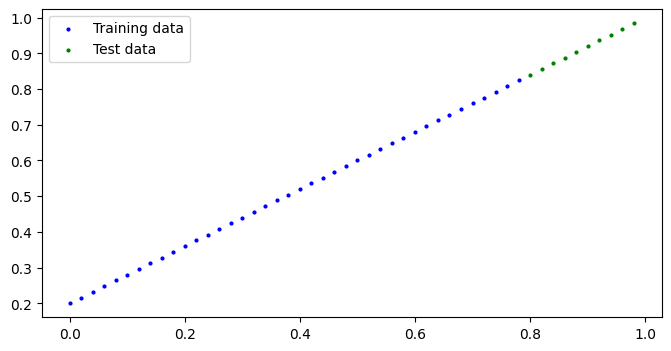

In [5]:
plot_predictions()

##2. Building a model
Now that we've got the data lets build ML model. For this, we will create a simple linear regression model. As we know, this model will learn about the parameters (weight) and (bias) to predict the outputs.

### Pytorch building fundamentals
Pytorch as generally four modules we use to create any kind of model.
- torch.nn: it contains all the building blocks for computational models.
- torch.nn.module: This is the base class for every model. If we are building any model in pytorch, the model should be subclassed with nn.module base class.
- torch.nn.Parameter: It is a special tensor used to store learnable paramters which can be used with nn.module
- torch.optim: It contains many optimized algorithms that tell the model how to upgrade the parameter using the gradient to reduce the loss.
- forward(): All subclasses of nn.module need a froward function to define the forward computations of the data.

In [6]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    #Initialize the parameters
    self.weight = nn.Parameter(torch.randn(1, requires_grad=True,
                                           dtype= torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True,
                                         dtype= torch.float))

  #Forward function which defines the computation on the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias

In [7]:
#Let's look at the contents of pytorch model
torch.manual_seed(42)

#Creating an instance of the model class
model0 = LinearRegressionModel()

#.parameter() function will return the parameters within the subcalss
list(model0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
#Let's also look at how the predictions will look like with this instance
#we predict with torch.inference_mode()
with torch.inference_mode():
  y_preds = model0(x_test)
y_preds

tensor([0.3982, 0.4049, 0.4116, 0.4184, 0.4251, 0.4318, 0.4386, 0.4453, 0.4520,
        0.4588])

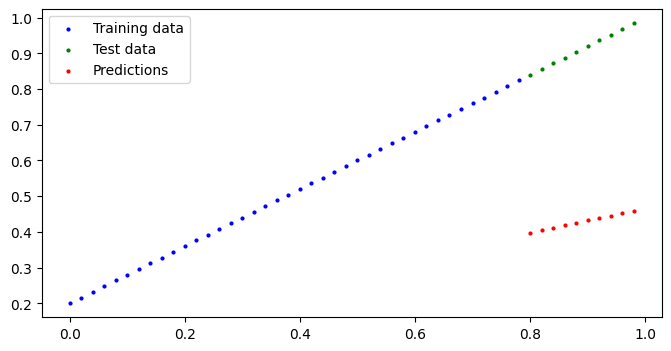

In [9]:
#Also lets visualize it
plot_predictions(predictions=y_preds)

As we can see, our predictions are quite terrible right now. This is to be expected as we start with random numbers.

Now we try to make the red dots as close to the green dots. To do this, we train or ML model with our train set that we split earlier.

##3. Training a Model
The main idea of training a model is to move from some unknown parameters to known(learned) paremters i.e., from a poor representation to a better representation of the data.

For this, in geneal we deal with two main concepts:
1. **Loss function**: Loss function measures how poor or wrong the representation of prediction of the model is. Pytorch provides many loss functions.

2. **Optimizer**: It takes into account the loss of the model through the loss function and adjusts the paremeters of the model. It used the gradient calculated during back propagation to adjust the params. Backpropagation computes how each param contributed to the error.

Also, specifically for pytorch we need:
- Training loop
- Testing loop

In [10]:
#Setting up Loss function
#For this simple LR model, we will use L1loss function
#L1loss is a criterion that measures the mean absolute error between x an y
lossfun = nn.L1Loss()

#Setting up an optimizer
#optim.SGD is the most famous optimizer
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.001)

**Note:** 'lr' is an hyperparameter (parameters set by us instead of the model).The learning rate determines the size of each update made to the model's parameters during training.

- A larger learning rate causes the parameters to change more in each update. This can speed up learning but may cause the optimizer to overshoot the minimum or fail to converge.
- A smaller learning rate results in smaller parameter updates. This usually leads to more stable learning but may require more training iterations to converge.

###Coding training and testing loop
Training loop involves the model going through the training data and learning about the relations between features and labels.

The loop involves these setps:
1. Loop through the code with certain no. of epochs. (Epoch is one loop through the code).
2. Forward pass or Forward propagation: The data will move through the forward() function of our model.
3. Calculate the loss with a loss function i.e., compare the forward pass predictions with ground truth values of the train set.
4. Optimizer zero grad: This set involves changing the gradient to zeros. This is because every change done by the optimizer will accumulate in each epoch by default. If we don't clear it then the gradients from previous epochs will be added to the current epoch.
5. Back Propagation
6. Optimizer step

In [23]:
torch.manual_seed(42)

#set the desired no of epochs
epochs = 1000

#setting the loop
for epoch in range(epochs):
  #Set the model in train mode
  """ setting the model in train mode will set all the parameters that requires
  to require gradients."""
  model0.train()

  #Forward pass the model
  y_pred = model0(x_train)

  #Calculate the loss using the loss function
  loss = lossfun(y_pred, y_train)

  #reset the gradients
  optimizer.zero_grad()

  #Backpropagation
  loss.backward()

  #Step the optimizer
  optimizer.step()

In [24]:
print(f"Loss: {loss}")
list(model0.parameters())

Loss: 0.04554139822721481


[Parameter containing:
 tensor([0.5736], requires_grad=True),
 Parameter containing:
 tensor([0.2951], requires_grad=True)]

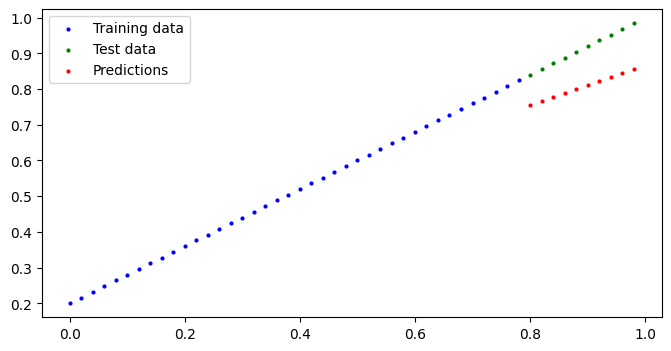

In [25]:
#with this we can see the learning steps of model
#we can see in the graph that the red dots are getting closer and closer
with torch.inference_mode():
  y_predicted = model0(x_test)

plot_predictions(predictions=y_predicted)